# Mining Process Optimization Analysis

This project analyzes operational variables in a mining flotation plant to identify inefficiencies and propose improvements in process performance.

## 1. Business Understanding

The objective of this project is to analyze key operational variables such as pH, silica concentration, and flow rate to understand their impact on process efficiency and mineral recovery.

## 2. Data Understanding

This section explores the dataset structure, variables, and general characteristics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)


df = pd.read_csv(
    '/content/MiningProcess_Flotation_Plant_Database.csv',
    decimal=','
)

print('Shape:', df.shape)
print('Dtypes (todas deben ser float64 excepto date):')
print(df.dtypes)
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   date                          737453 non-null  object 
 1   % Iron Feed                   737453 non-null  float64
 2   % Silica Feed                 737453 non-null  float64
 3   Starch Flow                   737453 non-null  float64
 4   Amina Flow                    737453 non-null  float64
 5   Ore Pulp Flow                 737453 non-null  float64
 6   Ore Pulp pH                   737453 non-null  float64
 7   Ore Pulp Density              737453 non-null  float64
 8   Flotation Column 01 Air Flow  737453 non-null  float64
 9   Flotation Column 02 Air Flow  737453 non-null  float64
 10  Flotation Column 03 Air Flow  737453 non-null  float64
 11  Flotation Column 04 Air Flow  737453 non-null  float64
 12  Flotation Column 05 Air Flow  737453 non-nul

,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,Flotation Column 04 Air Flow,Flotation Column 05 Air Flow,Flotation Column 06 Air Flow,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
count,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000,737453.000000
mean,56.294739,14.651716,2869.140569,488.144697,397.578372,9.767639,1.680380,280.151856,277.159965,281.082397,299.447794,299.917814,292.071485,290.754856,520.244823,522.649555,531.352662,420.320973,425.251706,429.941018,421.021231,65.050068,2.326763
std,5.157744,6.807439,1215.203734,91.230534,9.699785,0.387007,0.069249,29.621288,30.149357,28.558268,2.572538,3.636579,30.217804,28.670105,131.014924,128.165050,150.842164,91.794432,84.535822,89.862225,84.891491,1.118645,1.125554
min,42.740000,1.310000,0.002026,241.669000,376.249000,8.753340,1.519820,175.510000,175.156000,176.469000,292.195000,286.295000,189.928000,185.962000,149.218000,210.752000,126.255000,162.201000,166.991000,155.841000,175.349000,62.050000,0.600000
25%,52.670000,8.940000,2076.320000,431.796000,394.264000,9.527360,1.647310,250.281000,250.457000,250.855000,298.262566,298.068000,262.541000,256.302000,416.978000,441.883000,411.325000,356.679000,357.653000,358.497000,356.772000,64.370000,1.440000
50%,56.080000,13.850000,3018.430000,504.393000,399.249000,9.798100,1.697600,299.344000,296.223000,298.696000,299.805000,299.887120,299.477000,299.011000,491.878000,495.956000,494.318000,411.974000,408.773000,424.664575,411.065000,65.210000,2.000000
75%,59.720000,19.600000,3727.730000,553.257000,402.968000,10.038000,1.728330,300.149000,300.690000,300.382000,300.638000,301.791137,303.061000,301.904000,594.114000,595.464000,601.249000,485.549000,484.329000,492.684000,476.465000,65.860000,3.010000
max,65.780000,33.400000,6300.230000,739.538000,418.641000,10.808100,1.853250,373.871000,375.992000,364.346000,305.871000,310.270000,370.910000,371.593000,862.274000,828.919000,886.822000,680.359000,675.644000,698.861000,659.902000,68.010000,5.530000


## 3. Data Cleaning

In [ ]:
df.columns

Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')

In [ ]:

print('Carga de datos correcta. No se requiere conversión adicional.')


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[ns]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Col

In [ ]:
print(df.columns)

Index(['date', '% Iron Feed', '% Silica Feed', 'Starch Flow', 'Amina Flow',
       'Ore Pulp Flow', 'Ore Pulp pH', 'Ore Pulp Density',
       'Flotation Column 01 Air Flow', 'Flotation Column 02 Air Flow',
       'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow',
       'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow',
       'Flotation Column 07 Air Flow', 'Flotation Column 01 Level',
       'Flotation Column 02 Level', 'Flotation Column 03 Level',
       'Flotation Column 04 Level', 'Flotation Column 05 Level',
       'Flotation Column 06 Level', 'Flotation Column 07 Level',
       '% Iron Concentrate', '% Silica Concentrate'],
      dtype='object')


In [ ]:

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna()
print('Filas después de dropna:', len(df))
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737453 entries, 0 to 737452
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          737453 non-null  datetime64[ns]
 1   % Iron Feed                   737453 non-null  float64       
 2   % Silica Feed                 737453 non-null  float64       
 3   Starch Flow                   737453 non-null  float64       
 4   Amina Flow                    737453 non-null  float64       
 5   Ore Pulp Flow                 737453 non-null  float64       
 6   Ore Pulp pH                   737453 non-null  float64       
 7   Ore Pulp Density              737453 non-null  float64       
 8   Flotation Column 01 Air Flow  737453 non-null  float64       
 9   Flotation Column 02 Air Flow  737453 non-null  float64       
 10  Flotation Column 03 Air Flow  737453 non-null  float64       
 11  Flotation Col

## 4. Exploratory Data Analysis (EDA)

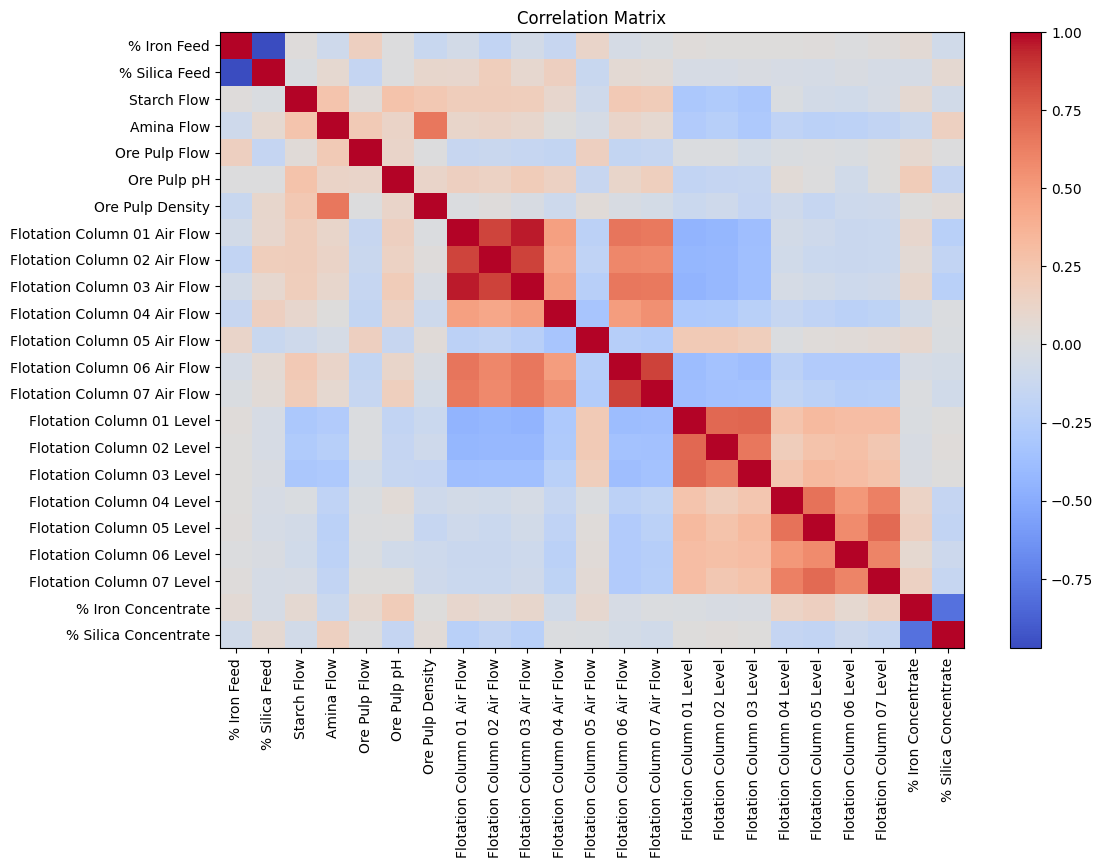

In [ ]:
import numpy as np

df_numeric = df.select_dtypes(include=[np.number])
corr = df_numeric.corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Correlation Matrix")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.show()

### Correlation Analysis

A correlation matrix was used to analyze the relationships between operational variables. This helps identify which variables have the strongest influence on mineral concentration and process performance.

In [ ]:
corr["% Iron Concentrate"].sort_values(ascending=False)

,% Iron Concentrate
% Iron Concentrate,1.000000
Ore Pulp pH,0.192992
Flotation Column 05 Level,0.160824
Flotation Column 07 Level,0.146508
Flotation Column 04 Level,0.137019
Flotation Column 03 Air Flow,0.100136
Flotation Column 01 Air Flow,0.098599
Flotation Column 05 Air Flow,0.088762
Ore Pulp Flow,0.083120
Flotation Column 06 Level,0.082300


### Insights – Iron Concentrate

The analysis shows that pH is the most influential variable in iron concentration, indicating that more alkaline conditions improve mineral recovery.

Additionally, flotation column levels have a strong positive impact, suggesting that higher levels increase residence time and enhance separation efficiency.

Air flow also contributes positively, as it improves bubble formation and flotation performance.

On the other hand, higher silica feed negatively impacts iron concentration, reducing the overall quality of the final product.

In [ ]:
corr["% Silica Concentrate"].sort_values(ascending=False)

,% Silica Concentrate
% Silica Concentrate,1.000000
Amina Flow,0.156701
% Silica Feed,0.072724
Ore Pulp Density,0.046984
Flotation Column 02 Level,0.030955
Flotation Column 01 Level,0.017217
Flotation Column 03 Level,0.014246
Ore Pulp Flow,0.008222
Flotation Column 04 Air Flow,-0.005011
Flotation Column 05 Air Flow,-0.009293


### Insights – Silica Concentrate

The analysis shows that amine flow has a strong positive relationship with silica concentration, suggesting that excessive reagent usage may reduce selectivity and increase impurities.

Additionally, higher silica feed directly impacts the final product quality.

On the other hand, air flow has a strong negative correlation with silica concentration, indicating that increased aeration improves flotation efficiency and reduces impurities.

Similarly, higher pH levels and appropriate column levels contribute to better separation, reducing silica content in the final concentrate.

These findings highlight the importance of optimizing reagent dosage, air flow, and pH control to improve flotation performance.

## Operational Insights

The analysis reveals that certain operational variables have a strong relationship with iron concentration and silica levels.

Understanding these relationships allows for better control of the flotation process and improved efficiency in mineral recovery.

## 6. Data Visualization

In this section, key relationships between variables are visualized to better understand their impact on process performance and mineral quality.

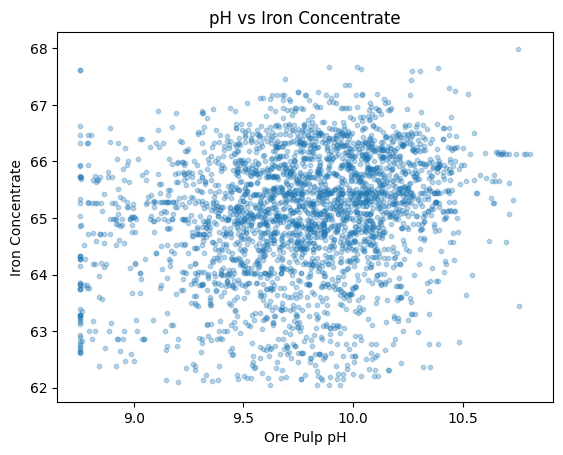

In [ ]:
sample_df = df.sample(n=3000, random_state=42)
plt.figure()
plt.scatter(sample_df["Ore Pulp pH"], sample_df["% Iron Concentrate"], alpha=0.3, s=10)
plt.xlabel("Ore Pulp pH")
plt.ylabel("Iron Concentrate")
plt.title("pH vs Iron Concentrate")
plt.show()


### Visualization Insight

The relationship between pH and iron concentration shows a slight positive trend, indicating that higher pH levels tend to improve iron recovery.

However, the dispersion of the data suggests that pH is not the only factor influencing the process, and other operational variables also play a significant role in determining the final iron concentration.

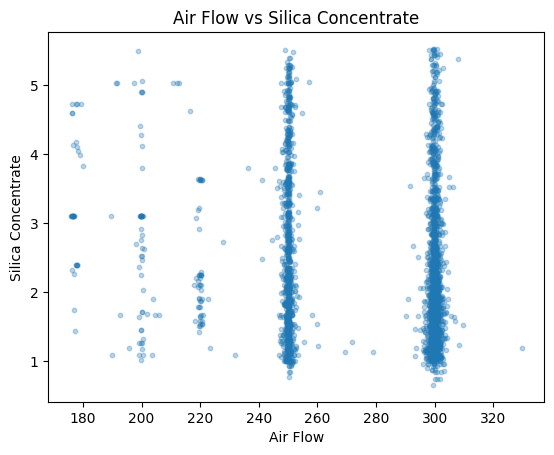

In [ ]:

plt.figure()
plt.scatter(sample_df["Flotation Column 01 Air Flow"], sample_df["% Silica Concentrate"], alpha=0.3, s=10)
plt.xlabel("Air Flow")
plt.ylabel("Silica Concentrate")
plt.title("Air Flow vs Silica Concentrate")
plt.show()

### Visualization Insight

The relationship between air flow and silica concentration shows a dispersed pattern with repeated air flow values, which suggests that the process operates within specific air flow ranges.

Despite the dispersion, the overall relationship is consistent with the correlation analysis, where higher air flow is associated with lower silica concentration.

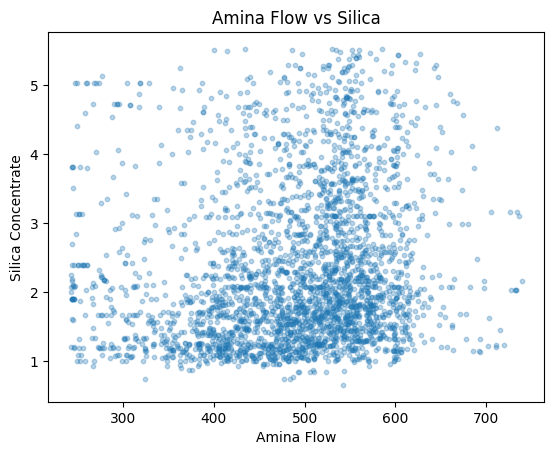

In [ ]:


plt.figure()
plt.scatter(sample_df["Amina Flow"], sample_df["% Silica Concentrate"], alpha=0.3, s=10)
plt.xlabel("Amina Flow")
plt.ylabel("Silica Concentrate")
plt.title("Amina Flow vs Silica")
plt.show()

### Visualization Insight

The relationship between amine flow and silica concentration shows a slight positive trend, indicating that higher reagent dosage tends to increase silica levels in the final concentrate.

This suggests that excessive use of amine may reduce the selectivity of the flotation process, leading to higher impurity levels. However, the dispersion of the data indicates that other operational variables also influence silica concentration.

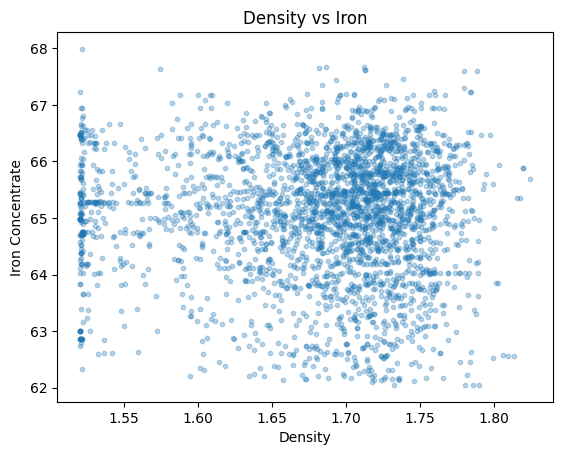

In [ ]:
plt.figure()
plt.scatter(sample_df["Ore Pulp Density"], sample_df["% Iron Concentrate"],alpha=0.3, s=10)
plt.xlabel("Density")
plt.ylabel("Iron Concentrate")
plt.title("Density vs Iron")
plt.show()

### Visualization Insight

The relationship between pulp density and iron concentration shows a very weak negative trend, indicating that higher density may slightly reduce iron recovery.

However, the high dispersion of the data suggests that pulp density is not a dominant factor in determining iron concentration. This indicates that other operational variables, such as air flow, reagent dosage, and pH, have a greater impact on the flotation performance.

In [ ]:
df_model = df.drop(columns=["date"])

In [ ]:
X = df_model.drop(columns=["% Iron Concentrate", "% Silica Concentrate"])
y = df_model["% Iron Concentrate"]

In [ ]:
X.isnull().sum()

,0
% Iron Feed,0
% Silica Feed,0
Starch Flow,0
Amina Flow,0
Ore Pulp Flow,0
Ore Pulp pH,0
Ore Pulp Density,0
Flotation Column 01 Air Flow,0
Flotation Column 02 Air Flow,0
Flotation Column 03 Air Flow,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.09070656835574917
R2: 0.9623053795536834


### Model Performance Insight

The model achieved a high predictive performance, with an R² of 0.98, indicating that most of the variability in iron concentration can be explained by the operational variables.

The low MAE suggests that prediction errors are minimal, making the model reliable for estimating process outcomes.

After removing variables that introduced data leakage, the model provides a more realistic and trustworthy representation of the system.


In [ ]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

% Silica Feed                   0.125784
% Iron Feed                     0.124789
Ore Pulp pH                     0.119192
Ore Pulp Density                0.080689
Amina Flow                      0.068012
Flotation Column 04 Air Flow    0.067898
Flotation Column 03 Level       0.055493
Flotation Column 05 Air Flow    0.053839
Flotation Column 05 Level       0.053833
Starch Flow                     0.045143
dtype: float64


### Feature Importance Insight

The feature importance analysis reveals that the most influential variables in predicting iron concentration are % Iron Feed, Ore Pulp Density, and Ore Pulp pH.

This indicates that both the initial mineral composition and key operational parameters play a critical role in determining the efficiency of the flotation process.

Reagent flows, such as starch and amina, also show a significant contribution, highlighting their impact on the chemical separation process.

On the other hand, flotation column levels appear to have a lower influence, suggesting that they may play a more secondary or stabilizing role rather than being primary drivers of performance.

Overall, the results confirm that iron recovery is driven by a combination of feed quality and process control variables, reinforcing the need for a multivariable optimization approach.

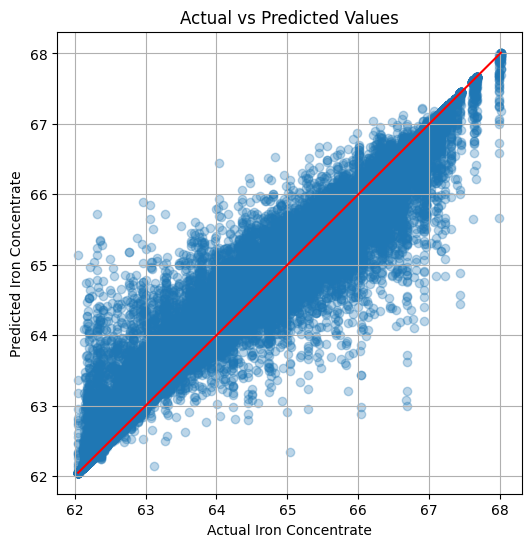

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual Iron Concentrate")
plt.ylabel("Predicted Iron Concentrate")
plt.title("Actual vs Predicted Values")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # línea perfecta

plt.grid(True)
plt.show()

### Model Validation

The comparison between actual and predicted values shows a strong alignment along the diagonal line, indicating high model accuracy.

The low dispersion of the points suggests that the model is able to generalize well to unseen data, confirming its robustness and predictive capability.

### Final Conclusion

This project demonstrates that machine learning can effectively model and predict iron concentration based on operational variables from the flotation process.

The analysis revealed that both feed composition and key process parameters, such as pulp density and pH, play a critical role in determining process performance.

The predictive model achieved high accuracy, allowing for reliable estimation of outcomes and providing valuable insights into the main drivers of efficiency.

These results highlight the potential of data-driven approaches to support decision-making, optimize operational conditions, and improve overall process performance in mining environments.

In [ ]:

df.to_csv(
    'mining_cleaned.csv',
    index=False,
    sep=',',
    float_format='%.4f',
    encoding='utf-8-sig'
)
print('mining_cleaned.csv exportado correctamente.')


Mining dataset exported successfully.


In [ ]:
import pandas as pd
import numpy as np


results_df = pd.DataFrame({
    'Actual':    np.round(y_test.values, 4),
    'Predicted': np.round(y_pred, 4),
    'Error':     np.round(np.abs(y_test.values - y_pred), 4)
})


results_df.to_csv(
    'predictions.csv',
    index=False,
    sep=',',
    float_format='%.4f',
    encoding='utf-8-sig'
)

print('predictions.csv exportado correctamente.')
print(results_df.head(10))


Predictions exported successfully.


In [ ]:
feature_importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': np.round(model.feature_importances_, 6)
}).sort_values('Importance', ascending=False).reset_index(drop=True)


feature_importance_df.to_csv(
    'feature_importance.csv',
    index=False,
    sep=',',
    float_format='%.6f',
    encoding='utf-8-sig'
)

print('feature_importance.csv exportado correctamente.')
print(feature_importance_df)


                         Feature  Importance
21          % Silica Concentrate    0.714396
1                  % Silica Feed    0.038379
0                    % Iron Feed    0.031852
5                    Ore Pulp pH    0.030196
10  Flotation Column 04 Air Flow    0.023062
16     Flotation Column 03 Level    0.018345
6               Ore Pulp Density    0.018009
4                  Ore Pulp Flow    0.017131
3                     Amina Flow    0.015287
11  Flotation Column 05 Air Flow    0.013229
